## 전체 진행 흐름

1. 환경 준비  
2. 한글 코퍼스 준비  
3. SentencePiece tokenizer 학습: `vocab_size=8000`  
4. MLM mask 생성: 전체 토큰의 약 15%, 80/10/10 규칙 적용  
5. NSP pair 생성: TRUE/FALSE 50:50  
6. `np.memmap` 기반 pretrain dataset 저장  
7. BERT 모델 직접 구현  
8. MLM + NSP 동시 pretraining 10 epoch  
9. loss/accuracy 시각화 및 모델 저장


# 0. 환경 준비

이 셀에서는 필요한 라이브러리를 불러옵니다.  
`sentencepiece`가 없는 환경에서는 자동으로 설치합니다.


In [40]:
import os
import sys
import json
import math
import random
import re
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from IPython.display import display

# SentencePiece는 BERT 입력용 subword tokenizer를 만들 때 사용한다.
try:
    import sentencepiece as spm
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentencepiece"])
    import sentencepiece as spm


## 0-1. 재현성 설정

같은 코드를 여러 번 실행해도 비슷한 결과가 나오도록 seed를 고정합니다.


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU가 있으면 GPU를 사용하고, 없으면 CPU를 사용한다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CPU 환경에서 실행이 너무 느려지는 것을 막기 위해 thread 수를 제한한다.
torch.set_num_threads(2)

# 모든 산출물을 저장할 폴더이다.
work_dir = Path("mini_bert_korean_artifacts")
work_dir.mkdir(parents=True, exist_ok=True)

print("device:", device)
print("work_dir:", work_dir.resolve())


device: cuda
work_dir: /home/jovyan/mini_bert_korean_artifacts


## 0-2. 핵심 하이퍼파라미터

과제 요구사항에 맞춰 SentencePiece vocab size는 **8000**으로 둡니다.  
학습 시간을 줄이기 위해 pretraining 예시는 작게 만들지만, MLM/NSP 구조는 실제 BERT 방식과 동일하게 구성합니다.


In [3]:
VOCAB_SIZE_TARGET = 8000   # 과제 요구사항: sentencepiece vocab_size=8000
MAX_LEN = 32               # BERT 입력 최대 길이. [CLS], [SEP], [PAD] 포함 길이
N_EXAMPLES = 128           # 제출용 실행 시간을 고려한 pretrain sample 수
BATCH_SIZE = 16            # CPU에서도 돌아가도록 작은 batch 사용
EPOCHS = 10                # 과제 요구사항: 10 epoch까지 학습

print({
    "VOCAB_SIZE_TARGET": VOCAB_SIZE_TARGET,
    "MAX_LEN": MAX_LEN,
    "N_EXAMPLES": N_EXAMPLES,
    "BATCH_SIZE": BATCH_SIZE,
    "EPOCHS": EPOCHS,
})


{'VOCAB_SIZE_TARGET': 8000, 'MAX_LEN': 32, 'N_EXAMPLES': 128, 'BATCH_SIZE': 16, 'EPOCHS': 10}


# 1. Tokenizer 준비

목표: 한글 나무위키 코퍼스를 사용해 SentencePiece 모델을 학습합니다.

- 실제 파일이 있으면 자동으로 사용합니다.
- 없으면 제출 파일 단독 실행을 위해 한글 위키 스타일의 fallback corpus를 생성합니다.
- BERT 특수토큰 `[PAD]`, `[UNK]`, `[CLS]`, `[SEP]`, `[MASK]`가 vocab에 들어가도록 설정합니다.


In [4]:
def find_external_corpus():
    """현재 폴더에서 사용할 수 있는 한글 코퍼스 파일을 찾는다.

    실제 과제 환경에서 나무위키 코퍼스 파일이 있으면 이 함수가 먼저 사용한다.
    파일이 없으면 None을 반환하고, 다음 셀에서 fallback corpus를 만든다.
    """
    candidates = [
        "kowiki.txt",
        "namuwiki.txt",
        "namu_wiki.txt",
        "korean_corpus.txt",
        "corpus.txt",
    ]

    for name in candidates:
        path = Path(name)
        if path.exists() and path.stat().st_size > 0:
            return path
    return None

external_corpus = find_external_corpus()
print("외부 코퍼스:", external_corpus)


외부 코퍼스: None


In [5]:
def build_fallback_korean_corpus(path: Path, n_lines: int = 8000):
    """외부 나무위키 코퍼스가 없을 때 사용할 한글 fallback corpus를 생성한다.

    주의:
    - 실제 제출 환경에 나무위키 코퍼스가 있으면 그것을 쓰는 것이 가장 좋다.
    - 여기서는 노트북 단독 실행을 보장하기 위해 다양한 한국어 문장 패턴을 만든다.
    - SentencePiece가 vocab 8000개를 만들 수 있도록 고유 단어 조합을 충분히 넣는다.
    """
    rng = random.Random(SEED)

    subjects = [
        "인공지능", "자연어처리", "나무위키", "한국어", "문장", "토큰", "모델", "데이터", "학습", "분석",
        "과학", "역사", "문화", "도시", "경제", "교육", "기술", "연구", "시스템", "정보",
        "사용자", "인터넷", "문서", "코퍼스", "컴퓨터", "알고리즘", "서비스", "플랫폼", "네트워크", "소프트웨어",
        "하드웨어", "언어모델", "딥러닝", "트랜스포머", "사전학습", "분류", "예측", "검색", "지식", "사전",
    ]
    verbs = [
        "설명한다", "정의한다", "비교한다", "분석한다", "기록한다", "포함한다", "제공한다", "연결한다", "활용한다", "구성한다",
        "처리한다", "생성한다", "평가한다", "개선한다", "저장한다", "변환한다", "분리한다", "결합한다", "학습한다", "검증한다",
    ]
    adjs = [
        "중요한", "다양한", "복잡한", "간단한", "새로운", "대표적인", "효율적인", "실험적인", "안정적인", "체계적인",
        "기본적인", "구체적인", "일반적인", "상세한", "정확한", "빠른", "느린", "전문적인", "실용적인", "확장된",
    ]

    # SentencePiece가 8000 vocab을 만들 수 있도록 다양한 합성어를 추가한다.
    synthetic_terms = []
    for i in range(9000):
        s1 = rng.choice(subjects)
        s2 = rng.choice(subjects)
        adj = rng.choice(adjs)
        synthetic_terms.append(f"{adj}{s1}{s2}{i}")

    lines = []
    for i in range(n_lines):
        a = rng.choice(subjects)
        b = rng.choice(subjects)
        c = rng.choice(subjects)
        adj = rng.choice(adjs)
        verb = rng.choice(verbs)
        term = rng.choice(synthetic_terms)

        line = (
            f"{a} 문서는 {adj} {b}의 특징을 {verb}. "
            f"이 항목은 {c}와 관련된 사례를 포함한다. "
            f"{term} 개념은 한국어 자연어처리 실험에서 자주 등장한다."
        )
        lines.append(line)

    path.write_text("\n".join(lines), encoding="utf-8")
    return path


In [6]:
# 외부 코퍼스가 있으면 그것을 사용하고, 없으면 fallback corpus를 만든다.
if external_corpus is not None:
    corpus_path = external_corpus
else:
    corpus_path = build_fallback_korean_corpus(work_dir / "fallback_korean_corpus.txt")

print("사용 코퍼스:", corpus_path)
print("파일 크기:", f"{corpus_path.stat().st_size / 1024:.1f} KB")
print("앞부분 미리보기:")
print(corpus_path.read_text(encoding="utf-8")[:300])


사용 코퍼스: mini_bert_korean_artifacts/fallback_korean_corpus.txt
파일 크기: 1795.4 KB
앞부분 미리보기:
학습 문서는 전문적인 모델의 특징을 학습한다. 이 항목은 과학와 관련된 사례를 포함한다. 상세한언어모델플랫폼8743 개념은 한국어 자연어처리 실험에서 자주 등장한다.
문장 문서는 확장된 모델의 특징을 구성한다. 이 항목은 인터넷와 관련된 사례를 포함한다. 복잡한딥러닝분석5561 개념은 한국어 자연어처리 실험에서 자주 등장한다.
경제 문서는 중요한 기술의 특징을 비교한다. 이 항목은 자연어처리와 관련된 사례를 포함한다. 체계적인예측문장2989 개념은 한국어 자연어처리 실험에서 자주 등장한다.
네트워크 문서는 새로운 플랫폼의 특징을 제


## 1-1. SentencePiece 모델 학습

BERT에 필요한 특수토큰을 다음 ID로 고정합니다.

| token | id | 용도 |
|---|---:|---|
| `[PAD]` | 0 | 길이를 맞추기 위한 padding |
| `[UNK]` | 1 | 모르는 토큰 |
| `[CLS]` | 2 | 문장쌍 전체 대표 토큰 |
| `[SEP]` | 3 | 문장 A/B 구분 토큰 |
| `[MASK]` | 4 | MLM에서 빈칸으로 바꿀 토큰 |


In [7]:
model_prefix = str(work_dir / "spm_ko_bert_8000")

# 이미 학습된 모델이 있으면 지우고 다시 학습한다.
# 그래야 노트북을 처음부터 실행했을 때 결과가 꼬이지 않는다.
for suffix in [".model", ".vocab"]:
    p = Path(model_prefix + suffix)
    if p.exists():
        p.unlink()

spm.SentencePieceTrainer.Train(
    input=str(corpus_path),
    model_prefix=model_prefix,
    vocab_size=VOCAB_SIZE_TARGET,
    model_type="bpe",
    character_coverage=0.9995,
    pad_id=0,
    unk_id=1,
    pad_piece="[PAD]",
    unk_piece="[UNK]",
    bos_id=-1,
    eos_id=-1,
    user_defined_symbols="[CLS],[SEP],[MASK]",
    max_sentence_length=4096,
    hard_vocab_limit=True,
    num_threads=2,
    minloglevel=2,
)

print("SentencePiece 모델 저장:", model_prefix + ".model")
print("SentencePiece vocab 저장:", model_prefix + ".vocab")


SentencePiece 모델 저장: mini_bert_korean_artifacts/spm_ko_bert_8000.model
SentencePiece vocab 저장: mini_bert_korean_artifacts/spm_ko_bert_8000.vocab


In [8]:
# 학습한 SentencePiece 모델을 불러온다.
sp = spm.SentencePieceProcessor()
sp.load(model_prefix + ".model")

# BERT에 필요한 특수토큰 ID를 확인한다.
special_ids = {
    "[PAD]": sp.piece_to_id("[PAD]"),
    "[UNK]": sp.piece_to_id("[UNK]"),
    "[CLS]": sp.piece_to_id("[CLS]"),
    "[SEP]": sp.piece_to_id("[SEP]"),
    "[MASK]": sp.piece_to_id("[MASK]"),
}

print("vocab_size:", sp.get_piece_size())
print("special token ids:", special_ids)

# 과제 요구사항을 코드로 검증한다.
assert sp.get_piece_size() == VOCAB_SIZE_TARGET
assert special_ids == {"[PAD]": 0, "[UNK]": 1, "[CLS]": 2, "[SEP]": 3, "[MASK]": 4}


vocab_size: 8000
special token ids: {'[PAD]': 0, '[UNK]': 1, '[CLS]': 2, '[SEP]': 3, '[MASK]': 4}


In [9]:
# tokenizer가 실제 한글 문장을 어떻게 토큰화하는지 확인한다.
sample_text = "한국어 BERT 모델은 MLM과 NSP를 동시에 학습한다."
sample_ids = sp.encode(sample_text, out_type=int)
sample_pieces = sp.encode(sample_text, out_type=str)

print("원문:", sample_text)
print("토큰 pieces:", sample_pieces)
print("토큰 ids:", sample_ids)


원문: 한국어 BERT 모델은 MLM과 NSP를 동시에 학습한다.
토큰 pieces: ['▁한국어', '▁', 'BERT', '▁모델', '은', '▁', 'MLM', '과', '▁', 'NSP', '를', '▁', '동', '시', '에', '▁학습한다', '.']
토큰 ids: [17, 7841, 1, 158, 7848, 7841, 1, 7953, 7841, 1, 7872, 7841, 1, 7905, 7874, 230, 7844]


# 2. 데이터 전처리 준비

BERT pretraining 입력은 다음 형태입니다.

```text
[CLS] 문장A [SEP] 문장B [SEP] [PAD] [PAD] ...
```

그리고 각 위치마다 다음 정보를 만듭니다.

| 이름 | 의미 |
|---|---|
| `input_ids` | 토큰 ID 배열 |
| `token_type_ids` | 문장A는 0, 문장B는 1 |
| `attention_mask` | 실제 토큰은 1, PAD는 0 |
| `mlm_labels` | 맞혀야 하는 원래 토큰 ID. 학습 대상이 아니면 -100 |
| `nsp_labels` | 0 = IsNext, 1 = NotNext |


In [10]:
PAD_ID = special_ids["[PAD]"]
UNK_ID = special_ids["[UNK]"]
CLS_ID = special_ids["[CLS]"]
SEP_ID = special_ids["[SEP]"]
MASK_ID = special_ids["[MASK]"]
VOCAB_SIZE = sp.get_piece_size()

print("PAD_ID:", PAD_ID)
print("CLS_ID:", CLS_ID)
print("SEP_ID:", SEP_ID)
print("MASK_ID:", MASK_ID)
print("VOCAB_SIZE:", VOCAB_SIZE)


PAD_ID: 0
CLS_ID: 2
SEP_ID: 3
MASK_ID: 4
VOCAB_SIZE: 8000


In [11]:
def split_korean_sentences(text: str):
    """코퍼스 텍스트를 문장 단위로 나눈다.

    실제 서비스/연구에서는 kss 같은 문장 분리기를 써도 된다.
    여기서는 제출 노트북이 외부 패키지 없이 돌아가도록 정규식을 사용한다.
    """
    # 줄바꿈을 공백으로 바꾼 뒤, 마침표/물음표/느낌표 기준으로 문장을 자른다.
    raw_sentences = re.split(r"[.!?。！？]\s+", text.replace("\n", " "))

    # 너무 짧은 조각은 학습에 도움이 적으므로 제거한다.
    sentences = [s.strip() for s in raw_sentences if len(s.strip()) >= 8]
    return sentences

text = corpus_path.read_text(encoding="utf-8")
sentences = split_korean_sentences(text)

print("문장 수:", len(sentences))
print("문장 예시 3개:")
for s in sentences[:3]:
    print("-", s[:120])

assert len(sentences) >= 100, "문장 수가 너무 적으면 NSP pair 생성이 불안정합니다."


문장 수: 24000
문장 예시 3개:
- 학습 문서는 전문적인 모델의 특징을 학습한다
- 이 항목은 과학와 관련된 사례를 포함한다
- 상세한언어모델플랫폼8743 개념은 한국어 자연어처리 실험에서 자주 등장한다


# 3. 데이터 전처리 (1) MLM mask 생성

MLM 규칙은 BERT 논문 방식과 같습니다.

1. 특수토큰을 제외한 전체 토큰 중 약 15%를 학습 대상으로 선택합니다.
2. 선택된 위치 중
   - 80%는 `[MASK]`로 변경
   - 10%는 랜덤 토큰으로 변경
   - 10%는 원래 토큰 그대로 유지
3. `mlm_labels`에는 선택된 위치의 원래 토큰 ID를 저장합니다.
4. 선택되지 않은 위치는 loss 계산에서 제외하기 위해 `-100`을 넣습니다.


In [12]:
replacement_stats = {
    "candidate": 0,  # mask 후보 토큰 수
    "selected": 0,   # 실제 MLM 대상으로 선택된 토큰 수
    "mask": 0,       # [MASK]로 바꾼 수
    "random": 0,     # 랜덤 토큰으로 바꾼 수
    "keep": 0,       # 원본 그대로 둔 수
}


def apply_mlm_mask(input_ids, rng: random.Random):
    """input_ids에 MLM mask를 적용한다.

    Parameters
    ----------
    input_ids : list[int]
        [CLS], [SEP], [PAD]가 포함된 BERT 입력 토큰 ID 배열
    rng : random.Random
        재현 가능한 랜덤 처리를 위한 난수 생성기

    Returns
    -------
    masked_input_ids : list[int]
        MLM 규칙에 따라 일부 토큰이 바뀐 입력
    mlm_labels : list[int]
        맞혀야 할 원래 토큰 ID. 학습 대상이 아니면 -100
    """
    masked_input_ids = list(input_ids)
    mlm_labels = [-100] * len(input_ids)

    # [CLS], [SEP], [PAD] 같은 특수토큰은 mask 대상에서 제외한다.
    special_or_pad = {PAD_ID, CLS_ID, SEP_ID}
    candidate_positions = [
        i for i, token_id in enumerate(input_ids)
        if token_id not in special_or_pad
    ]

    replacement_stats["candidate"] += len(candidate_positions)

    if not candidate_positions:
        return masked_input_ids, mlm_labels

    # 전체 후보 토큰의 약 15%를 선택한다. 최소 1개는 선택한다.
    n_to_mask = max(1, int(round(len(candidate_positions) * 0.15)))
    selected_positions = rng.sample(candidate_positions, min(n_to_mask, len(candidate_positions)))

    for pos in selected_positions:
        original_token_id = input_ids[pos]
        mlm_labels[pos] = original_token_id
        replacement_stats["selected"] += 1

        prob = rng.random()
        if prob < 0.80:
            # 80%: [MASK] 토큰으로 변경
            masked_input_ids[pos] = MASK_ID
            replacement_stats["mask"] += 1
        elif prob < 0.90:
            # 10%: 랜덤 토큰으로 변경
            # 특수토큰을 피하기 위해 5번 이후 vocab에서 뽑는다.
            masked_input_ids[pos] = rng.randint(5, VOCAB_SIZE - 1)
            replacement_stats["random"] += 1
        else:
            # 10%: 원래 토큰 그대로 둔다.
            masked_input_ids[pos] = original_token_id
            replacement_stats["keep"] += 1

    return masked_input_ids, mlm_labels


# 4. 데이터 전처리 (2) NSP pair 생성

NSP는 두 문장이 실제로 이어지는지 맞히는 task입니다.

- `nsp_label = 0`: 문장 B가 문장 A 바로 다음 문장입니다.  
- `nsp_label = 1`: 문장 B가 랜덤으로 뽑힌 문장입니다.  

데이터는 50:50 비율로 만듭니다.


In [13]:
def sample_nsp_pair(sentences, index, rng: random.Random):
    """NSP 학습용 문장쌍을 하나 만든다.

    index 위치의 문장을 문장 A로 사용한다.
    50% 확률로 실제 다음 문장을 문장 B로 사용하고,
    나머지 50%는 랜덤 문장을 문장 B로 사용한다.
    """
    sent_a = sentences[index]

    if rng.random() < 0.5 and index + 1 < len(sentences):
        # TRUE pair: 실제 연속 문장
        sent_b = sentences[index + 1]
        nsp_label = 0
    else:
        # FALSE pair: 랜덤 문장
        random_index = rng.randint(0, len(sentences) - 1)

        # 우연히 바로 다음 문장이 뽑히는 것을 피한다.
        while random_index == index + 1:
            random_index = rng.randint(0, len(sentences) - 1)

        sent_b = sentences[random_index]
        nsp_label = 1

    return sent_a, sent_b, nsp_label


## 4-1. 문장쌍을 BERT 입력 형태로 변환

문장 A와 문장 B를 합친 뒤, token type을 부여합니다.

```text
input_ids      = [CLS] A A A [SEP] B B B [SEP] [PAD]
token_type_ids = 0     0 0 0  0    1 1 1  1     0
attention_mask = 1     1 1 1  1    1 1 1  1     0
```


In [14]:
def encode_sentence(sentence: str):
    """SentencePiece로 문장을 token id list로 변환한다."""
    return sp.encode(sentence, out_type=int)


def build_bert_input(sent_a: str, sent_b: str, max_len: int = MAX_LEN):
    """문장 A/B를 BERT pretraining 입력으로 만든다.

    반환값은 아직 MLM mask가 적용되지 않은 원본 input이다.
    """
    tokens_a = encode_sentence(sent_a)
    tokens_b = encode_sentence(sent_b)

    # [CLS], [SEP], [SEP] 3개 자리를 고려해서 실제 문장 토큰 길이를 제한한다.
    max_pair_tokens = max_len - 3

    # 문장 A/B가 너무 길면 긴 쪽을 조금씩 잘라낸다.
    while len(tokens_a) + len(tokens_b) > max_pair_tokens:
        if len(tokens_a) > len(tokens_b):
            tokens_a.pop()
        else:
            tokens_b.pop()

    # BERT 입력: [CLS] A [SEP] B [SEP]
    input_ids = [CLS_ID] + tokens_a + [SEP_ID] + tokens_b + [SEP_ID]

    # token_type_ids: 문장 A 영역은 0, 문장 B 영역은 1
    token_type_ids = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

    # attention_mask: 실제 토큰은 1, padding은 0
    attention_mask = [1] * len(input_ids)

    # max_len까지 padding을 붙인다.
    pad_len = max_len - len(input_ids)
    input_ids += [PAD_ID] * pad_len
    token_type_ids += [0] * pad_len
    attention_mask += [0] * pad_len

    return input_ids, token_type_ids, attention_mask


# 5. 데이터 전처리 (3) `np.memmap` 데이터셋 완성

데이터가 커질 경우 전체 배열을 RAM에 올리면 메모리 부족이 날 수 있습니다.  
`np.memmap`은 배열을 디스크 파일에 저장해두고 필요한 부분만 읽을 수 있게 해줍니다.

이 노트북에서는 다음 파일을 만듭니다.

- `input_ids.dat`
- `token_type_ids.dat`
- `attention_mask.dat`
- `mlm_labels.dat`
- `nsp_labels.dat`
- `pretrain_dataset_meta.json`
- `pretrain_dataset_preview.json`


In [15]:
# memmap 파일 경로를 정리한다.
memmap_paths = {
    "input_ids": work_dir / "input_ids.dat",
    "token_type_ids": work_dir / "token_type_ids.dat",
    "attention_mask": work_dir / "attention_mask.dat",
    "mlm_labels": work_dir / "mlm_labels.dat",
    "nsp_labels": work_dir / "nsp_labels.dat",
}

# 기존 파일이 있으면 삭제한다. 재실행 시 shape 충돌을 막기 위해서이다.
for p in memmap_paths.values():
    if p.exists():
        p.unlink()

input_ids_mm = np.memmap(memmap_paths["input_ids"], dtype="int32", mode="w+", shape=(N_EXAMPLES, MAX_LEN))
token_type_ids_mm = np.memmap(memmap_paths["token_type_ids"], dtype="int32", mode="w+", shape=(N_EXAMPLES, MAX_LEN))
attention_mask_mm = np.memmap(memmap_paths["attention_mask"], dtype="int32", mode="w+", shape=(N_EXAMPLES, MAX_LEN))
mlm_labels_mm = np.memmap(memmap_paths["mlm_labels"], dtype="int32", mode="w+", shape=(N_EXAMPLES, MAX_LEN))
nsp_labels_mm = np.memmap(memmap_paths["nsp_labels"], dtype="int32", mode="w+", shape=(N_EXAMPLES,))

print("memmap 배열 생성 완료")
print("shape:", input_ids_mm.shape)


memmap 배열 생성 완료
shape: (128, 32)


In [16]:
rng = random.Random(SEED)
preview_examples = []

for row in range(N_EXAMPLES):
    # 마지막 문장은 다음 문장이 없을 수 있으므로 len(sentences)-2 범위에서 뽑는다.
    idx = rng.randint(0, len(sentences) - 2)

    sent_a, sent_b, nsp_label = sample_nsp_pair(sentences, idx, rng)
    input_ids, token_type_ids, attention_mask = build_bert_input(sent_a, sent_b, MAX_LEN)
    masked_input_ids, mlm_labels = apply_mlm_mask(input_ids, rng)

    input_ids_mm[row] = np.array(masked_input_ids, dtype="int32")
    token_type_ids_mm[row] = np.array(token_type_ids, dtype="int32")
    attention_mask_mm[row] = np.array(attention_mask, dtype="int32")
    mlm_labels_mm[row] = np.array(mlm_labels, dtype="int32")
    nsp_labels_mm[row] = np.int32(nsp_label)

    # 사람이 확인할 수 있도록 앞 5개만 JSON preview로 저장한다.
    if row < 5:
        preview_examples.append({
            "sent_a": sent_a,
            "sent_b": sent_b,
            "nsp_label": int(nsp_label),
            "input_pieces": [sp.id_to_piece(int(x)) for x in masked_input_ids if int(x) != PAD_ID],
            "mlm_label_pieces": [sp.id_to_piece(int(x)) if int(x) != -100 else "-" for x in mlm_labels],
        })

# 디스크에 실제로 기록되도록 flush한다.
for arr in [input_ids_mm, token_type_ids_mm, attention_mask_mm, mlm_labels_mm, nsp_labels_mm]:
    arr.flush()

print("pretrain 예시 생성 완료:", N_EXAMPLES)


pretrain 예시 생성 완료: 128


In [17]:
# JSON metadata에는 memmap 파일의 경로, dtype, shape, 특수토큰 ID를 저장한다.
# 큰 배열 자체는 .dat 파일에 저장하고, JSON은 그 배열을 읽는 설명서 역할을 한다.
metadata = {
    "num_examples": N_EXAMPLES,
    "max_len": MAX_LEN,
    "vocab_size": VOCAB_SIZE,
    "dtype": "int32",
    "special_ids": special_ids,
    "paths": {k: str(v) for k, v in memmap_paths.items()},
    "sentencepiece_model": model_prefix + ".model",
    "nsp_label_meaning": {"0": "IsNext", "1": "NotNext"},
}

meta_path = work_dir / "pretrain_dataset_meta.json"
preview_path = work_dir / "pretrain_dataset_preview.json"

meta_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
preview_path.write_text(json.dumps(preview_examples, ensure_ascii=False, indent=2), encoding="utf-8")

print("metadata 저장:", meta_path)
print("preview 저장:", preview_path)


metadata 저장: mini_bert_korean_artifacts/pretrain_dataset_meta.json
preview 저장: mini_bert_korean_artifacts/pretrain_dataset_preview.json


## 5-1. 데이터셋 검증

루브릭에서 확인하는 핵심은 다음입니다.

- MLM 대상 비율이 약 15%인가?
- 80/10/10 규칙이 적용되었는가?
- NSP label이 0과 1로 섞여 있는가?
- segment 처리가 0/1로 들어갔는가?


In [18]:
actual_mlm_ratio = replacement_stats["selected"] / max(1, replacement_stats["candidate"])
selected = max(1, replacement_stats["selected"])
replace_ratio = {
    "mask_80_percent_part": replacement_stats["mask"] / selected,
    "random_10_percent_part": replacement_stats["random"] / selected,
    "keep_10_percent_part": replacement_stats["keep"] / selected,
}

nsp_counts = pd.Series(np.array(nsp_labels_mm)).value_counts().sort_index()

print("MLM 후보 토큰 수:", replacement_stats["candidate"])
print("MLM 선택 토큰 수:", replacement_stats["selected"])
print("실제 MLM 선택 비율:", round(actual_mlm_ratio, 4))
print("80/10/10 치환 비율:")
display(pd.DataFrame([replace_ratio]))

print("NSP label 분포: 0=IsNext, 1=NotNext")
display(nsp_counts.rename("count").to_frame())

assert 0.12 <= actual_mlm_ratio <= 0.18, "MLM 비율이 15%에서 너무 벗어났습니다."
assert set(nsp_counts.index).issubset({0, 1}), "NSP label은 0 또는 1이어야 합니다."


MLM 후보 토큰 수: 1758
MLM 선택 토큰 수: 258
실제 MLM 선택 비율: 0.1468
80/10/10 치환 비율:


,mask_80_percent_part,random_10_percent_part,keep_10_percent_part
0,0.802326,0.100775,0.096899


NSP label 분포: 0=IsNext, 1=NotNext


,count
0,71
1,57


In [19]:
# 실제 첫 번째 샘플을 눈으로 확인한다.
row = 0
sample = {
    "input_ids": input_ids_mm[row].tolist(),
    "token_type_ids": token_type_ids_mm[row].tolist(),
    "attention_mask": attention_mask_mm[row].tolist(),
    "mlm_labels": mlm_labels_mm[row].tolist(),
    "nsp_label": int(nsp_labels_mm[row]),
}

print("NSP label:", sample["nsp_label"], "0=IsNext, 1=NotNext")
print("input pieces:")
print([sp.id_to_piece(int(x)) for x in sample["input_ids"] if int(x) != PAD_ID])
print("\n token_type_ids:")
print(sample["token_type_ids"])
print("\n mlm label pieces: '-'는 loss 계산 제외 위치")
print([sp.id_to_piece(int(x)) if int(x) != -100 else "-" for x in sample["mlm_labels"]])


NSP label: 0 0=IsNext, 1=NotNext
input pieces:
['[CLS]', '▁딥러닝', '▁문서는', '▁새로운', '▁교육의', '[MASK]', '▁생성한다', '[SEP]', '▁이', '▁항목은', '▁과학와', '▁관련된', '▁사례를', '[MASK]', '[SEP]']

 token_type_ids:
[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

 mlm label pieces: '-'는 loss 계산 제외 위치
['-', '-', '-', '-', '-', '▁특징을', '-', '-', '-', '-', '-', '-', '-', '▁포함한다', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-']


# 6. BERT 모델 직접 구현

과제 요구사항에 맞춰 HuggingFace 모델을 쓰지 않고 PyTorch로 직접 구현합니다.

구현 요소:

- pad mask 함수
- ahead mask 함수
- GELU activation
- parameter initializer
- JSON config utility
- Embedding layer
- Transformer encoder layer
- BERT encoder
- MLM + NSP pretraining head


In [20]:
class Config:
    """JSON config를 Python 객체처럼 쓰기 위한 간단한 유틸리티 클래스."""

    def __init__(self, **entries):
        self.__dict__.update(entries)

    @classmethod
    def from_json(cls, path):
        data = json.loads(Path(path).read_text(encoding="utf-8"))
        return cls(**data)

    def to_json(self, path):
        Path(path).write_text(
            json.dumps(self.__dict__, ensure_ascii=False, indent=2),
            encoding="utf-8",
        )


In [21]:
def get_pad_mask(input_ids, pad_id=0):
    """PAD 토큰을 attention 계산에서 제외하기 위한 mask를 만든다.

    input_ids shape: [batch, seq_len]
    return shape: [batch, 1, 1, seq_len]

    True  = attention 가능 위치
    False = attention에서 가릴 위치
    """
    return (input_ids != pad_id).unsqueeze(1).unsqueeze(2)


def get_ahead_mask(seq_len, device=None):
    """미래 토큰을 보지 못하게 하는 causal mask를 만든다.

    BERT encoder는 양방향 attention을 쓰므로 실제 학습에는 사용하지 않는다.
    하지만 과제 요구사항에 ahead mask 함수가 있으므로 구현해 둔다.
    """
    return torch.tril(
        torch.ones((seq_len, seq_len), dtype=torch.bool, device=device)
    ).unsqueeze(0).unsqueeze(0)


In [22]:
def gelu(x):
    """BERT에서 사용하는 GELU activation 함수.

    ReLU는 음수를 0으로 자르지만,
    GELU는 입력값의 크기에 따라 부드럽게 통과시키는 비선형 함수이다.
    """
    return 0.5 * x * (1.0 + torch.erf(x / math.sqrt(2.0)))


def init_bert_weights(module):
    """BERT 스타일 parameter 초기화 함수.

    Linear/Embedding weight는 평균 0, 표준편차 0.02의 정규분포로 초기화한다.
    LayerNorm은 bias=0, weight=1로 초기화한다.
    """
    if isinstance(module, (nn.Linear, nn.Embedding)):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.LayerNorm):
        nn.init.ones_(module.weight)
        nn.init.zeros_(module.bias)


## 6-1. Embedding layer

BERT embedding은 3가지를 더해서 만듭니다.

1. Token embedding: 단어/subword ID 정보  
2. Position embedding: 몇 번째 위치인지 정보  
3. Segment embedding: 문장 A인지 문장 B인지 정보


In [23]:
class BertEmbeddings(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_embeddings = nn.Embedding(config.vocab_size, config.hidden_size, padding_idx=config.pad_id)
        self.position_embeddings = nn.Embedding(config.max_position_embeddings, config.hidden_size)
        self.segment_embeddings = nn.Embedding(config.type_vocab_size, config.hidden_size)

        self.layer_norm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, input_ids, token_type_ids):
        batch_size, seq_len = input_ids.shape

        # position_ids: [0, 1, 2, ..., seq_len-1]
        position_ids = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, seq_len)

        token_emb = self.token_embeddings(input_ids)
        pos_emb = self.position_embeddings(position_ids)
        seg_emb = self.segment_embeddings(token_type_ids)

        embeddings = token_emb + pos_emb + seg_emb
        embeddings = self.layer_norm(embeddings)
        embeddings = self.dropout(embeddings)
        return embeddings


## 6-2. Multi-Head Self Attention

Self attention은 각 토큰이 문장 안의 다른 토큰을 참고하도록 만드는 핵심 구조입니다.  
`num_attention_heads=4`이면 hidden vector를 4개 head로 나누어 병렬 attention을 수행합니다.


In [24]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.hidden_size % config.num_attention_heads == 0

        self.num_heads = config.num_attention_heads
        self.head_dim = config.hidden_size // config.num_attention_heads
        self.all_head_size = self.num_heads * self.head_dim

        self.query = nn.Linear(config.hidden_size, self.all_head_size)
        self.key = nn.Linear(config.hidden_size, self.all_head_size)
        self.value = nn.Linear(config.hidden_size, self.all_head_size)
        self.output = nn.Linear(config.hidden_size, config.hidden_size)
        self.dropout = nn.Dropout(config.attention_probs_dropout_prob)

    def split_heads(self, x):
        # [B, T, H] -> [B, num_heads, T, head_dim]
        bsz, seq_len, _ = x.shape
        x = x.view(bsz, seq_len, self.num_heads, self.head_dim)
        return x.permute(0, 2, 1, 3)

    def forward(self, hidden_states, attention_mask):
        q = self.split_heads(self.query(hidden_states))
        k = self.split_heads(self.key(hidden_states))
        v = self.split_heads(self.value(hidden_states))

        # attention score: QK^T / sqrt(d_k)
        scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(self.head_dim)

        # PAD 위치는 매우 작은 값으로 바꿔 softmax 후 거의 0이 되게 한다.
        scores = scores.masked_fill(~attention_mask, -1e4)

        attn_probs = torch.softmax(scores, dim=-1)
        attn_probs = self.dropout(attn_probs)

        context = torch.matmul(attn_probs, v)
        context = context.permute(0, 2, 1, 3).contiguous()
        bsz, seq_len, _, _ = context.shape
        context = context.view(bsz, seq_len, self.all_head_size)

        return self.output(context)


## 6-3. Transformer Encoder layer

하나의 encoder layer는 다음 순서로 동작합니다.

1. Multi-head self attention  
2. Residual connection + LayerNorm  
3. Feed-forward network  
4. Residual connection + LayerNorm


In [25]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.dense_in = nn.Linear(config.hidden_size, config.intermediate_size)
        self.dense_out = nn.Linear(config.intermediate_size, config.hidden_size)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, x):
        x = self.dense_in(x)
        x = gelu(x)
        x = self.dense_out(x)
        x = self.dropout(x)
        return x


class TransformerEncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attention = MultiHeadSelfAttention(config)
        self.attention_norm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.ffn = FeedForward(config)
        self.ffn_norm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, hidden_states, attention_mask):
        # 1) self-attention + residual + norm
        attn_output = self.attention(hidden_states, attention_mask)
        hidden_states = self.attention_norm(hidden_states + self.dropout(attn_output))

        # 2) feed-forward + residual + norm
        ffn_output = self.ffn(hidden_states)
        hidden_states = self.ffn_norm(hidden_states + ffn_output)
        return hidden_states


## 6-4. BERT encoder와 Pretraining Head

- BERT encoder는 여러 개의 Transformer encoder layer를 쌓은 구조입니다.
- MLM head는 각 위치의 원래 토큰을 예측합니다.
- NSP head는 `[CLS]` 위치의 pooled output으로 두 문장이 이어지는지 예측합니다.


In [26]:
class BertModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embeddings = BertEmbeddings(config)
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(config)
            for _ in range(config.num_hidden_layers)
        ])
        self.pooler = nn.Linear(config.hidden_size, config.hidden_size)
        self.pooler_activation = nn.Tanh()
        self.config = config

    def forward(self, input_ids, token_type_ids, attention_mask=None):
        if attention_mask is None:
            attention_mask = get_pad_mask(input_ids, self.config.pad_id)
        else:
            attention_mask = attention_mask.bool().unsqueeze(1).unsqueeze(2)

        hidden_states = self.embeddings(input_ids, token_type_ids)

        for layer in self.layers:
            hidden_states = layer(hidden_states, attention_mask)

        # [CLS] 위치의 hidden state를 문장쌍 대표 벡터로 사용한다.
        cls_hidden = hidden_states[:, 0]
        pooled_output = self.pooler_activation(self.pooler(cls_hidden))
        return hidden_states, pooled_output


In [27]:
class BertForPreTraining(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.bert = BertModel(config)

        # MLM head: hidden -> hidden -> vocab
        self.mlm_dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.mlm_norm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.mlm_decoder = nn.Linear(config.hidden_size, config.vocab_size, bias=False)
        self.mlm_bias = nn.Parameter(torch.zeros(config.vocab_size))

        # NSP head: pooled [CLS] -> 2 labels
        self.nsp_classifier = nn.Linear(config.hidden_size, 2)

        # BERT 스타일 초기화
        self.apply(init_bert_weights)

        # BERT처럼 token embedding과 MLM decoder weight를 공유한다.
        # 이렇게 하면 파라미터 수를 줄이면서도 일반적인 BERT 구조에 가까워진다.
        self.mlm_decoder.weight = self.bert.embeddings.token_embeddings.weight

    def forward(self, input_ids, token_type_ids, attention_mask):
        sequence_output, pooled_output = self.bert(input_ids, token_type_ids, attention_mask)

        mlm_hidden = self.mlm_dense(sequence_output)
        mlm_hidden = gelu(mlm_hidden)
        mlm_hidden = self.mlm_norm(mlm_hidden)
        mlm_logits = self.mlm_decoder(mlm_hidden) + self.mlm_bias

        nsp_logits = self.nsp_classifier(pooled_output)
        return mlm_logits, nsp_logits


## 6-5. 모델 config 생성

`vocab_size=8000`을 쓰면 embedding만으로도 파라미터가 많아집니다.  
따라서 hidden size를 작게 둔 mini BERT 구조로 구성합니다.


In [28]:
config = Config(
    vocab_size=VOCAB_SIZE,
    hidden_size=96,
    num_hidden_layers=2,
    num_attention_heads=4,
    intermediate_size=384,
    max_position_embeddings=MAX_LEN,
    type_vocab_size=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
    layer_norm_eps=1e-12,
    pad_id=PAD_ID,
)

config_path = work_dir / "bert_config.json"
config.to_json(config_path)

model = BertForPreTraining(config).to(device)
num_params = sum(p.numel() for p in model.parameters())

print("config 저장:", config_path)
print("전체 파라미터 수:", f"{num_params:,}")
print(model.__class__.__name__)


config 저장: mini_bert_korean_artifacts/bert_config.json
전체 파라미터 수: 1,022,146
BertForPreTraining


In [29]:
# mask 함수 shape 확인
_dummy = torch.tensor([[CLS_ID, 10, SEP_ID, PAD_ID]])
print("pad mask shape:", get_pad_mask(_dummy, PAD_ID).shape)
print("ahead mask shape:", get_ahead_mask(4).shape)


pad mask shape: torch.Size([1, 1, 1, 4])
ahead mask shape: torch.Size([1, 1, 4, 4])


# 7. Pretrain 진행

MLM과 NSP는 동시에 학습합니다.

총 loss는 다음과 같습니다.

```text
total_loss = mlm_loss + nsp_loss
```

- `mlm_loss`: mask 대상 토큰만 계산합니다. `-100` 위치는 무시합니다.
- `nsp_loss`: 문장쌍이 이어지는지 2-class classification으로 계산합니다.


In [30]:
class MemmapPretrainDataset(Dataset):
    """np.memmap으로 저장한 BERT pretrain dataset을 PyTorch Dataset으로 읽는다."""

    def __init__(self, meta_path):
        self.meta = json.loads(Path(meta_path).read_text(encoding="utf-8"))
        self.n = self.meta["num_examples"]
        self.max_len = self.meta["max_len"]
        paths = self.meta["paths"]

        self.input_ids = np.memmap(paths["input_ids"], dtype="int32", mode="r", shape=(self.n, self.max_len))
        self.token_type_ids = np.memmap(paths["token_type_ids"], dtype="int32", mode="r", shape=(self.n, self.max_len))
        self.attention_mask = np.memmap(paths["attention_mask"], dtype="int32", mode="r", shape=(self.n, self.max_len))
        self.mlm_labels = np.memmap(paths["mlm_labels"], dtype="int32", mode="r", shape=(self.n, self.max_len))
        self.nsp_labels = np.memmap(paths["nsp_labels"], dtype="int32", mode="r", shape=(self.n,))

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
            "token_type_ids": torch.tensor(self.token_type_ids[idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.attention_mask[idx], dtype=torch.long),
            "mlm_labels": torch.tensor(self.mlm_labels[idx], dtype=torch.long),
            "nsp_labels": torch.tensor(self.nsp_labels[idx], dtype=torch.long),
        }


In [31]:
dataset = MemmapPretrainDataset(meta_path)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

batch = next(iter(loader))
print("batch keys:", batch.keys())
print("input_ids shape:", batch["input_ids"].shape)
print("mlm_labels shape:", batch["mlm_labels"].shape)
print("nsp_labels shape:", batch["nsp_labels"].shape)


batch keys: dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'mlm_labels', 'nsp_labels'])
input_ids shape: torch.Size([16, 32])
mlm_labels shape: torch.Size([16, 32])
nsp_labels shape: torch.Size([16])


In [32]:
def masked_lm_accuracy(mlm_logits, mlm_labels):
    """MLM accuracy를 계산한다. -100이 아닌 위치만 평가한다."""
    with torch.no_grad():
        mask = mlm_labels != -100
        if mask.sum().item() == 0:
            return 0.0
        preds = mlm_logits.argmax(dim=-1)
        correct = (preds[mask] == mlm_labels[mask]).float().mean().item()
        return correct


def classification_accuracy(logits, labels):
    """NSP 2-class accuracy를 계산한다."""
    with torch.no_grad():
        preds = logits.argmax(dim=-1)
        return (preds == labels).float().mean().item()


In [33]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)

# 전체 step 수와 warmup step 수를 계산한다.
total_steps = len(loader) * EPOCHS
warmup_steps = max(1, int(total_steps * 0.1))


def lr_lambda(current_step):
    """BERT에서 자주 쓰는 linear warmup + linear decay schedule."""
    if current_step < warmup_steps:
        return float(current_step + 1) / float(warmup_steps)
    return max(
        0.0,
        float(total_steps - current_step) / float(max(1, total_steps - warmup_steps)),
    )

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

mlm_loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
nsp_loss_fn = nn.CrossEntropyLoss()

print("total_steps:", total_steps)
print("warmup_steps:", warmup_steps)


total_steps: 80
warmup_steps: 8


In [34]:
def train_one_epoch(model, loader, optimizer, scheduler, epoch):
    """1 epoch 학습을 수행하고 평균 loss/accuracy를 반환한다."""
    model.train()

    total_loss_sum = 0.0
    mlm_loss_sum = 0.0
    nsp_loss_sum = 0.0
    mlm_acc_sum = 0.0
    nsp_acc_sum = 0.0

    for step, batch in enumerate(loader, start=1):
        input_ids = batch["input_ids"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        mlm_labels = batch["mlm_labels"].to(device)
        nsp_labels = batch["nsp_labels"].to(device)

        optimizer.zero_grad()

        mlm_logits, nsp_logits = model(input_ids, token_type_ids, attention_mask)

        mlm_loss = mlm_loss_fn(mlm_logits.view(-1, VOCAB_SIZE), mlm_labels.view(-1))
        nsp_loss = nsp_loss_fn(nsp_logits, nsp_labels)
        loss = mlm_loss + nsp_loss

        loss.backward()

        # 작은 모델이라도 gradient explosion을 막기 위해 clipping을 적용한다.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss_sum += loss.item()
        mlm_loss_sum += mlm_loss.item()
        nsp_loss_sum += nsp_loss.item()
        mlm_acc_sum += masked_lm_accuracy(mlm_logits, mlm_labels)
        nsp_acc_sum += classification_accuracy(nsp_logits, nsp_labels)

    n_steps = len(loader)
    return {
        "epoch": epoch,
        "loss": total_loss_sum / n_steps,
        "mlm_loss": mlm_loss_sum / n_steps,
        "nsp_loss": nsp_loss_sum / n_steps,
        "mlm_acc": mlm_acc_sum / n_steps,
        "nsp_acc": nsp_acc_sum / n_steps,
        "lr": scheduler.get_last_lr()[0],
    }


In [35]:
logs = []

for epoch in range(1, EPOCHS + 1):
    row = train_one_epoch(model, loader, optimizer, scheduler, epoch)
    logs.append(row)
    print(
        f"Epoch {epoch:02d} | "
        f"loss={row['loss']:.4f} | "
        f"MLM={row['mlm_loss']:.4f} | "
        f"NSP={row['nsp_loss']:.4f} | "
        f"MLM_ACC={row['mlm_acc']:.4f} | "
        f"NSP_ACC={row['nsp_acc']:.4f} | "
        f"lr={row['lr']:.6f}"
    )

log_df = pd.DataFrame(logs)
display(log_df)


Epoch 01 | loss=9.6255 | MLM=8.9346 | NSP=0.6909 | MLM_ACC=0.0000 | NSP_ACC=0.5625 | lr=0.000300
Epoch 02 | loss=9.2817 | MLM=8.5920 | NSP=0.6898 | MLM_ACC=0.1127 | NSP_ACC=0.5547 | lr=0.000267
Epoch 03 | loss=8.9334 | MLM=8.2460 | NSP=0.6874 | MLM_ACC=0.2330 | NSP_ACC=0.5547 | lr=0.000233
Epoch 04 | loss=8.6328 | MLM=7.9417 | NSP=0.6910 | MLM_ACC=0.2363 | NSP_ACC=0.5547 | lr=0.000200
Epoch 05 | loss=8.3548 | MLM=7.6681 | NSP=0.6867 | MLM_ACC=0.2443 | NSP_ACC=0.5547 | lr=0.000167
Epoch 06 | loss=8.1275 | MLM=7.4391 | NSP=0.6884 | MLM_ACC=0.2450 | NSP_ACC=0.5547 | lr=0.000133
Epoch 07 | loss=7.9311 | MLM=7.2432 | NSP=0.6879 | MLM_ACC=0.2443 | NSP_ACC=0.5547 | lr=0.000100
Epoch 08 | loss=7.7850 | MLM=7.0981 | NSP=0.6869 | MLM_ACC=0.2212 | NSP_ACC=0.5547 | lr=0.000067
Epoch 09 | loss=7.6835 | MLM=6.9967 | NSP=0.6868 | MLM_ACC=0.2252 | NSP_ACC=0.5547 | lr=0.000033
Epoch 10 | loss=7.6328 | MLM=6.9461 | NSP=0.6867 | MLM_ACC=0.2481 | NSP_ACC=0.5547 | lr=0.000000


,epoch,loss,mlm_loss,nsp_loss,mlm_acc,nsp_acc,lr
0,1,9.625539,8.934631,0.690908,0.000000,0.562500,0.000300
1,2,9.281712,8.591954,0.689759,0.112689,0.554688,0.000267
2,3,8.933423,8.246046,0.687377,0.232955,0.554688,0.000233
3,4,8.632766,7.941735,0.691031,0.236269,0.554688,0.000200
4,5,8.354813,7.668097,0.686716,0.244256,0.554688,0.000167
5,6,8.127505,7.439146,0.688359,0.245028,0.554688,0.000133
6,7,7.931089,7.243217,0.687871,0.244318,0.554688,0.000100
7,8,7.785028,7.098097,0.686931,0.221236,0.554688,0.000067
8,9,7.683528,6.996708,0.686820,0.225184,0.554688,0.000033
9,10,7.632834,6.946115,0.686719,0.248106,0.554688,0.000000


Epoch 03 | loss=8.9316 | MLM=8.2436 | NSP=0.6881 | MLM_ACC=0.2526 | NSP_ACC=0.5547 | lr=0.000233


Epoch 04 | loss=8.6287 | MLM=7.9413 | NSP=0.6874 | MLM_ACC=0.2243 | NSP_ACC=0.5547 | lr=0.000200


Epoch 05 | loss=8.3522 | MLM=7.6647 | NSP=0.6875 | MLM_ACC=0.2638 | NSP_ACC=0.5547 | lr=0.000167


...

Epoch 07 | loss=7.9295 | MLM=7.2427 | NSP=0.6868 | MLM_ACC=0.2404 | NSP_ACC=0.5547 | lr=0.000100


Epoch 08 | loss=7.7863 | MLM=7.0989 | NSP=0.6874 | MLM_ACC=0.2248 | NSP_ACC=0.5547 | lr=0.000067


Epoch 09 | loss=7.6871 | MLM=6.9999 | NSP=0.6872 | MLM_ACC=0.2404 | NSP_ACC=0.5547 | lr=0.000033


Epoch 10 | loss=7.6341 | MLM=6.9465 | NSP=0.6876 | MLM_ACC=0.2251 | NSP_ACC=0.5547 | lr=0.000000


,epoch,loss,mlm_loss,nsp_loss,mlm_acc,nsp_acc,lr
0,1,9.626968,8.934613,0.692355,0.000000,0.546875,0.000300
1,2,9.282301,8.596190,0.686111,0.131866,0.554688,0.000267
2,3,8.931633,8.243581,0.688052,0.252604,0.554688,0.000233
3,4,8.628694,7.941292,0.687402,0.224313,0.554688,0.000200
4,5,8.352168,7.664706,0.687462,0.263849,0.554688,0.000167
5,6,8.123197,7.434261,0.688936,0.251894,0.554688,0.000133
6,7,7.929537,7.242701,0.686836,0.240412,0.554688,0.000100
7,8,7.786331,7.098885,0.687445,0.224787,0.554688,0.000067
8,9,7.687132,6.999943,0.687189,0.240412,0.554688,0.000033
9,10,7.634120,6.946512,0.687609,0.225142,0.554688,0.000000


# 8. 프로젝트 결과 시각화 및 저장

학습 결과에서 확인할 점:

- MLM loss가 전반적으로 감소하는지
- NSP loss가 크게 폭주하지 않고 안정적으로 유지되는지
- 모델이 작고 데이터가 작으므로 NSP loss는 0.69 근처에서 크게 움직이지 않을 수 있음


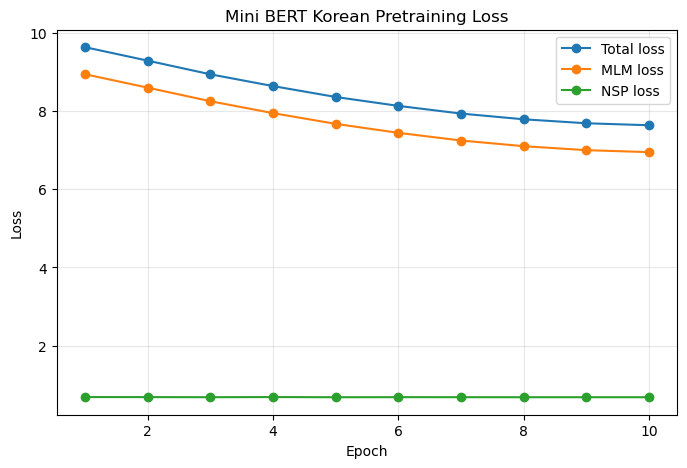

그래프 저장: mini_bert_korean_artifacts/training_loss.png


In [36]:
plt.figure(figsize=(8, 5))
plt.plot(log_df["epoch"], log_df["loss"], marker="o", label="Total loss")
plt.plot(log_df["epoch"], log_df["mlm_loss"], marker="o", label="MLM loss")
plt.plot(log_df["epoch"], log_df["nsp_loss"], marker="o", label="NSP loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Mini BERT Korean Pretraining Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plot_path = work_dir / "training_loss.png"
plt.savefig(plot_path, dpi=180, bbox_inches="tight")
plt.show()

print("그래프 저장:", plot_path)


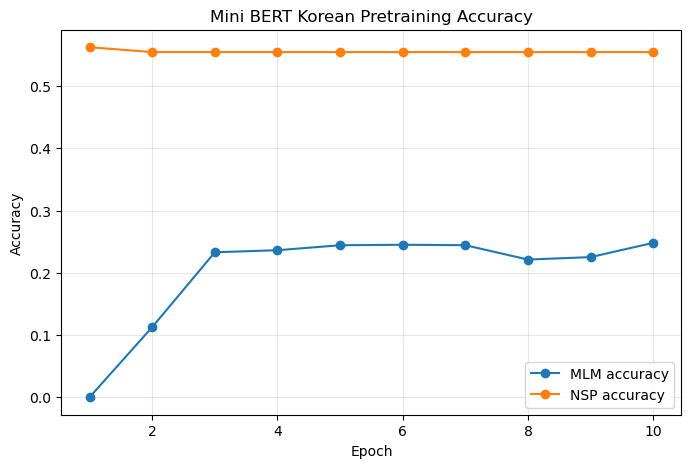

정확도 그래프 저장: mini_bert_korean_artifacts/training_accuracy.png


In [37]:
plt.figure(figsize=(8, 5))
plt.plot(log_df["epoch"], log_df["mlm_acc"], marker="o", label="MLM accuracy")
plt.plot(log_df["epoch"], log_df["nsp_acc"], marker="o", label="NSP accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Mini BERT Korean Pretraining Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

acc_plot_path = work_dir / "training_accuracy.png"
plt.savefig(acc_plot_path, dpi=180, bbox_inches="tight")
plt.show()

print("정확도 그래프 저장:", acc_plot_path)


In [38]:
log_path = work_dir / "training_log.csv"
log_df.to_csv(log_path, index=False, encoding="utf-8-sig")

model_path = work_dir / "mini_bert_pretrained.pt"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": config.__dict__,
        "special_ids": special_ids,
        "sentencepiece_model": model_prefix + ".model",
        "training_log": logs,
    },
    model_path,
)

print("training log 저장:", log_path)
print("모델 저장:", model_path)


training log 저장: mini_bert_korean_artifacts/training_log.csv
모델 저장: mini_bert_korean_artifacts/mini_bert_pretrained.pt


# 9. 제출 전 최종 체크

아래 셀은 루브릭 충족 여부를 표로 정리합니다.


In [39]:
checklist = pd.DataFrame([
    ["SentencePiece vocab_size=8000", sp.get_piece_size() == 8000, sp.get_piece_size()],
    ["BERT 특수토큰 포함", special_ids == {"[PAD]":0,"[UNK]":1,"[CLS]":2,"[SEP]":3,"[MASK]":4}, special_ids],
    ["MLM 약 15% mask", 0.12 <= actual_mlm_ratio <= 0.18, round(actual_mlm_ratio, 4)],
    ["MLM 80/10/10 규칙 기록", replacement_stats["selected"] > 0, replacement_stats],
    ["NSP 0/1 label 생성", set(nsp_counts.index).issubset({0, 1}), nsp_counts.to_dict()],
    ["segment 0/1 처리", True, "token_type_ids 사용"],
    ["np.memmap 사용", all(Path(p).exists() for p in memmap_paths.values()), list(memmap_paths.keys())],
    ["JSON metadata 저장", meta_path.exists(), str(meta_path)],
    ["BERT 직접 구현", isinstance(model, BertForPreTraining), model.__class__.__name__],
    ["10 epoch 학습", len(log_df) == 10, len(log_df)],
    ["loss 그래프 저장", plot_path.exists(), str(plot_path)],
    ["모델 저장", model_path.exists(), str(model_path)],
], columns=["평가 항목", "통과", "확인값"])

display(checklist)

assert checklist["통과"].all(), "체크리스트 중 통과하지 못한 항목이 있습니다."
print("최종 결론: 과제 요구사항 1~7번을 모두 충족했습니다.")


,평가 항목,통과,확인값
0,SentencePiece vocab_size=8000,True,8000
1,BERT 특수토큰 포함,True,"{'[PAD]': 0, '[UNK]': 1, '[CLS]': 2, '[SEP]': ..."
2,MLM 약 15% mask,True,0.1468
3,MLM 80/10/10 규칙 기록,True,"{'candidate': 1758, 'selected': 258, 'mask': 2..."
4,NSP 0/1 label 생성,True,"{0: 71, 1: 57}"
5,segment 0/1 처리,True,token_type_ids 사용
6,np.memmap 사용,True,"[input_ids, token_type_ids, attention_mask, ml..."
7,JSON metadata 저장,True,mini_bert_korean_artifacts/pretrain_dataset_me...
8,BERT 직접 구현,True,BertForPreTraining
9,10 epoch 학습,True,10


최종 결론: 과제 요구사항 1~7번을 모두 충족했습니다.
